# SPRINT 8.1

Aquesta pràctica permetrà explorar com es poden utilitzar eines de visualització avançades en Python per a interpretar i presentar dades de manera efectiva, proporcionant una oportunitat valuosa per a millorar les habilitats analítiques i tècniques. 

### Nivell 1

Realitza la connexió en Python amb el MySQL Workbench per a carregar tota la informació que tens en les taules. 


In [1]:
# !pip install mysql-connector-python
# !pip install numpy

* Creo la coneccion con MySQL importando el conector.
* Importo también el módulo Error desde el paquete mysql.connector que permite manejar errores específicos que puedan ocurrir durante la conexión a la BBDD: captura el tipo de error y muestra un mensaje.

In [ ]:
import mysql.connector 

from mysql.connector import Error 

try:
    connection = mysql.connector.connect(host='localhost', database='orders', user='root', password='Mariposa88')
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)

Connected to MySQL Server version  8.0.31
You're connected to database:  ('orders',)


* Importo todas las librerías para el analisis de datos y la creación de gráficos que pueda necesitar.
* Y creo un diccionario que almacene la base de datos transformando las tablas en dataframes: creando un cursor para ejecutar las consultas y obteniendo el listado de las tablas de la base de datos. Leeremos cada tabla como un dataframe, la almacenaremos en el diccionario e imprimiremos sus nombres a no ser que haya algún error ( y de ser así el error se imprimirá en pantalla) y luego cerraremos la coneccion.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    cursor = connection.cursor()
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()
    db_orders = {}

    for table in tables:
        table_name = table[0]  
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql(query, connection)  
        db_orders[table_name] = df  

    for table_name, df in db_orders.items():
        print(f"Tabla: {table_name}")

except Error as e:
    print("Error al conectar a la base de datos:", e)

finally:
    if connection.is_connected():
        cursor.close()
        connection.close()

Tabla: card_status
Tabla: companies
Tabla: credit_cards
Tabla: products
Tabla: sales
Tabla: transaction
Tabla: users


/var/folders/yz/twv78p_926s4djnv9zwvtf7c0000gn/T/ipykernel_3676/614771222.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


* Visualizo la información y los 5 primeros registros de todas las tablas de la Base de Datos para confirmar que los datos se hayan cargado adecuadamente:

In [3]:
card_status_df = db_orders['card_status']
print(card_status_df.info())
print(card_status_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   credit_card_id  275 non-null    object
 1   status          275 non-null    object
dtypes: object(2)
memory usage: 4.4+ KB
None
  credit_card_id  status
0       CcU-2938  active
1       CcU-2945  active
2       CcU-2952  active
3       CcU-2959  active
4       CcU-2966  active


In [4]:
companies_df = db_orders['companies']
print(companies_df.info())
print(companies_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            100 non-null    object
 1   company_name  100 non-null    object
 2   phone         100 non-null    object
 3   email         100 non-null    object
 4   country       100 non-null    object
 5   website       100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB
None
       id                 company_name           phone  \
0  b-2222    Ac Fermentum Incorporated  06 85 56 52 33   
1  b-2226     Magna A Neque Industries  04 14 44 64 62   
2  b-2230                  Fusce Corp.  08 14 97 58 85   
3  b-2234    Convallis In Incorporated  06 66 57 29 50   
4  b-2238  Ante Iaculis Nec Foundation  08 23 04 99 53   

                              email        country  \
0  donec.porttitor.tellus@yahoo.net        Germany   
1       risus.donec.nibh@icloud.org      Australia   
2    

In [5]:
credit_cards_df = db_orders['credit_cards']
print(credit_cards_df.info())
print(credit_cards_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             275 non-null    object
 1   user_id        275 non-null    int64 
 2   iban           275 non-null    object
 3   pan            275 non-null    object
 4   pin            275 non-null    object
 5   cvv            275 non-null    object
 6   track1         275 non-null    object
 7   track2         275 non-null    object
 8   expiring_date  275 non-null    object
dtypes: int64(1), object(8)
memory usage: 19.5+ KB
None
         id  user_id                          iban                 pan   pin  \
0  CcU-2938      275    TR301950312213576817638661    5424465566813633  3257   
1  CcU-2945      274  DO26854763748537475216568689    5142423821948828  9080   
2  CcU-2952      273        BG45IVQL52710525608255    4556 453 55 5287  4598   
3  CcU-2959      272         CR7242477244335841

In [36]:
products_df = db_orders['products']
print(products_df.info())
print(products_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            100 non-null    object 
 1   product_name  100 non-null    object 
 2   price         100 non-null    float64
 3   colour        100 non-null    object 
 4   weight        100 non-null    float64
 5   warehouse_id  100 non-null    object 
dtypes: float64(2), object(4)
memory usage: 4.8+ KB
None
    id      product_name   price   colour  weight warehouse_id
0    1  Direwolf Stannis  161.11  #7c7c7c     1.0         WH-4
1   10    Karstark Dorne  119.52  #f4f4f4     2.4        WH--5
2  100        south duel   40.43  #6d6d6d     3.0       WH--95
3   11    Karstark Dorne   49.70  #141414     2.7        WH--6
4   12     duel Direwolf  181.60  #a8a8a8     2.1        WH--7


In [7]:
sales_df = db_orders['sales']
print(sales_df.info())
print(sales_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1355 non-null   object
 1   product_id      1355 non-null   object
dtypes: object(2)
memory usage: 21.3+ KB
None
                         transaction_id product_id
0  02C6201E-D90A-1859-B4EE-88D2986D3B02         71
1  02C6201E-D90A-1859-B4EE-88D2986D3B02         19
2  02C6201E-D90A-1859-B4EE-88D2986D3B02          1
3  0466A42E-47CF-8D24-FD01-C0B689713128         97
4  0466A42E-47CF-8D24-FD01-C0B689713128         47


In [8]:
transaction_df = db_orders['transaction']
print(transaction_df.info())
print(transaction_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              587 non-null    object        
 1   credit_card_id  587 non-null    object        
 2   company_id      587 non-null    object        
 3   timestamp       587 non-null    datetime64[ns]
 4   amount          587 non-null    float64       
 5   declined        587 non-null    int64         
 6   products_id     587 non-null    object        
 7   user_id         587 non-null    int64         
 8   latitude        587 non-null    object        
 9   longitude       587 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 46.0+ KB
None
                                     id credit_card_id company_id  \
0  02C6201E-D90A-1859-B4EE-88D2986D3B02       CcU-2938     b-2362   
1  0466A42E-47CF-8D24-FD01-C0B689713128       

In [24]:
users_df = db_orders['users']
print(users_df.info())
print(users_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           275 non-null    int64 
 1   name         275 non-null    object
 2   surname      275 non-null    object
 3   phone        275 non-null    object
 4   email        275 non-null    object
 5   birth_date   275 non-null    object
 6   country      275 non-null    object
 7   city         275 non-null    object
 8   postal_code  275 non-null    object
 9   adress       275 non-null    object
dtypes: int64(1), object(9)
memory usage: 21.6+ KB
None
   id     name    surname           phone                              email  \
0   1     Zeus     Gamble  1-282-581-0551       interdum.enim@protonmail.edu   
1   2  Garrett  Mcconnell  (718) 257-2412  integer.vitae.nibh@protonmail.org   
2   3   Ciaran   Harrison  (522) 598-1365           interdum.feugiat@aol.org   
3   4   Howard   Stafford  

Realitzaràs una visualització per a cada exercici. Comenta el que et crida l'atenció de graficar aquesta variable, justifica l'elecció del gràfic i interpreta els resultats en funció de les teves dades.

### Exercici 1
Una variable numèrica.


* En mi caso voy a usar la variable 'price' de la tabla 'products' y la representaré con un histograma porque quiero ver si hay algun patron en el precio de los productos, por ejemplo: si hay más productos de precios altos o bajos o si el precio de los productos es medio.

* Uso sns.displot() de la columna 'price' de la tabla 'products' añadiendole la kde (que es la linea de tendencia) y seleccionando el color verde.

- sns.set_theme(style="darkgrid") pinta una cuadricula gris de fondo para visualizar mejor los valores obtenidos.
- plt title() nos sirve para añadirle el título al gráfico.
- plt.xlabel() y plt.ylabel() nos permiten añadirle titulos al los ejes x e y respectivamente.
- plt.show() nos muestra el gráfico



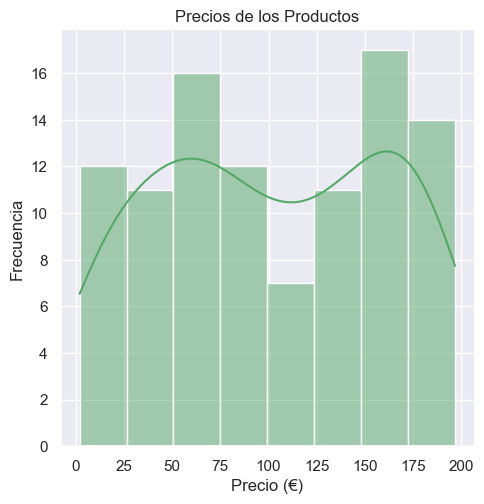

In [10]:
sns.set_theme(style="darkgrid") 
sns.displot(products_df["price"], kde=True, color="g")

plt.title("Precios de los Productos") 
plt.ylabel("Frecuencia") 
plt.xlabel("Precio (€)") 
plt.show()

Como se puede observar a simple vista no hay una tendencia especifíca en los precios de los productos sino que tenemos una amplia variedad. Siendo relativamente mayor en los extremos, o sea, tenemos un poco más cantidad de productos con precios altos: entre 150 y 175€, y precios medio-bajos: de 50 a 75€, y menor en el rango medio: de 100 a 125€.

Mi intención al graficar el histograma de los precios de los productos era analizar si nuestros productos eran más bien de alta gama o estaban comprendidos en un rango más amplio y creo que esta segunda clasificación es la más acertada.

### Exercici 2
Dues variables numèriques.

* Voy a trabajar con las variables: 'price' y 'peso' de la tabla: 'products', representandolas en un regplot de seaborn (gráfico de dispersión con regresión lineal) porque quiero ver si hay una relación entre ambas variables, o sea, si el aumento/disminución de una de ellas influye en la otra de alguna manera.

- line_kws={} nos permite elegir el formato de la linea de regresión, en mi caso: color negro, ancho de 1.5 y grado de transparencia de 0.5 que hace que la línea de regresión sea semi-transparente.
- En el color de los puntos del gráfico de dispersión he vuelto a elegir verde.

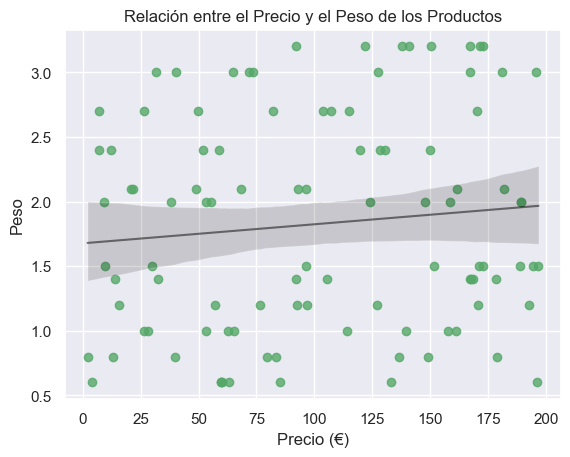

In [11]:
sns.set_theme(style="darkgrid")
sns.regplot(x=products_df["price"], y=products_df["weight"], line_kws={"color": "black", "linewidth": 1.5, "alpha": 0.5}, color="g",)

plt.title("Relación entre el Precio y el Peso de los Productos")
plt.ylabel("Peso")
plt.xlabel("Precio (€)") 
plt.show()

Mi hipotesis al graficar estas dos variables era que los productos más pesados suelen ser más grandes y por tanto más costosos (más material invertido en su fabricación, etc...); pero nada más lejos de la verdad en este caso, ya que en el gráfico anterior no se observa ninguna relacion entre las variables numéricas que elegí, estas no siguen ningun tipo de distribución, sino que los puntos estan igualmente distribuidos por toda la gráfica y esto se ve reflejado también en la linea de regresión. 

Por lo antereriormente mencionado podemos concluir que el peso de los productos no tiene un impacto importante en su precio, sino que el precio varia independientemente de el peso de los productos.

### Exercici 3
Una variable categòrica.

* En este caso elijo la variable: 'colour' de la tabla: 'products' y la represento con un gráfico de barras o barplot porque quiero ver la distribución, en este caso, de los 10 colores más frecuentes en los productos.

* Primero importo la librería 'MaxNLocator' de 'matplotlib.ticker' que me permitirá elegir que los valores en el 'eje y' sean números enteros.

* Luego cuento las ocurrencias de cada uno de los colores almacenados en la columna color y filtro solo los 10 colores más frecuentes utilizando head(10) y lo almaceno en una nueva variable. Ordeno estos colores por frecuencia para guardarlos en una lista (que almacenaré en la variable 'palette') que me servirá para asignar cada color a su columna en el gráfico.

* Utilizo hue=filtered_top_df["colour"] (qque no aporta nueva información porque x ya agrupa los datos por color) para asignar un color distinto a cada barra, según la paleta definida en palette. Ya que, sin hue, Seaborn asignaría un solo color a todas las barras.

* Y order me sirve para que el orden de el nombre de los colores en el eje y su color en las barras sea coincidente ya que los ordeno ambos por la frecuencia del color.

* Por ultimo añado la paletta de los colores creados a la gráfica y oculto la leyenda ya que no me interesa en este caso.


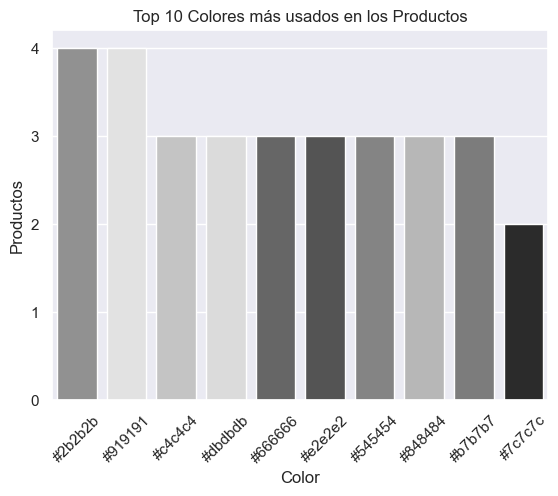

In [13]:
from matplotlib.ticker import MaxNLocator

colour_counts = products_df["colour"].value_counts()
top_colours = colour_counts.head(10).index
filtered_top_df = products_df[products_df["colour"].isin(top_colours)]
sorted_colours_top = filtered_top_df["colour"].value_counts().index
palette_top = list(sorted_colours_top)

ax = sns.countplot(x=filtered_top_df["colour"], hue=filtered_top_df["colour"], order=sorted_colours_top, palette=palette_top, legend=False)

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=45)
plt.xlabel("Color")
plt.ylabel("Productos")
plt.title("Top 10 Colores más usados en los Productos")
plt.show()

* Ahora hago lo mismo pero con los 10 colores menos frecuentes. Para esto utilizo tail() en vez de head() para que me de los 10 colores menos frecuentes.

* El resto del código es igual.

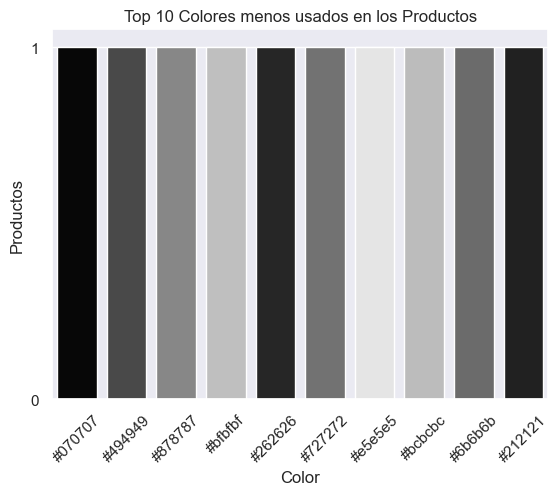

In [14]:
bot_colours = colour_counts.tail(10).index
filtered_bottom_df = products_df[products_df["colour"].isin(bot_colours)]
sorted_colours_bottom = filtered_bottom_df["colour"].value_counts().index
palette_bottom = list(sorted_colours_bottom)

ax = sns.countplot(x=filtered_bottom_df["colour"], hue=filtered_bottom_df["colour"], order=sorted_colours_bottom, palette=palette_bottom, legend=False)

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=45)
plt.xlabel("Color")
plt.ylabel("Productos")
plt.title("Top 10 Colores menos usados en los Productos")
plt.show()

Mi idea al hacer este analisis era descubrir que colores eran los más utilizados (y los menos utilizados) a la hora de fabricar los productos de la base de datos y poder discenir si quizas había alguna estrategia de marketing detrás de estás elecciones, mi sorpresa ha sido descubrir que todos los colores de los productos están en la gama de los grises, lo cuál complica bastante el extraer conclusiones.

Lo que podemos concluir al observar ambos gráficos es que el color no influye en la cantidad de productos, o sea, los 10 colores más utilizados son diferentes tonos de grises y los 10 menos utilizados también.

* Es importante aclarar que cada color en esta serie de colores no se trata de una tonalidad fija sino que tiene un rango de más claro a más oscuro, es por eso que podría variar el tono exacto al cambiar de programa a utilizar (o sea los colores que vemos en Python no serán los mismos que en PowerBI).

### Exercici 4
Una variable categòrica i una numèrica.


* En este ejercicio continuaré trabajando con la variable 'colour' y la relacionaré con la variable 'price' de la tabla: 'products', representando dicha relación a través de  un boxplot o gráfico de cajas y bigotes, porque quiero ver si los 10 colores más frecuentes se corresponden con los productos de mayor precio.

* Además de las funciones (y variables creadas por mi) utilizadas en los dos gráficos anteriores, añadimos plt.ylim() que me permite delimitar el rango de numeros que comprende el 'eje y' y plt.xticks() que me permite hacer una rotación de 45º de los nombres de los colores para que no se solapen entre ellos (esta ultima ya la usaba antes pero no la expliqué en su momento).

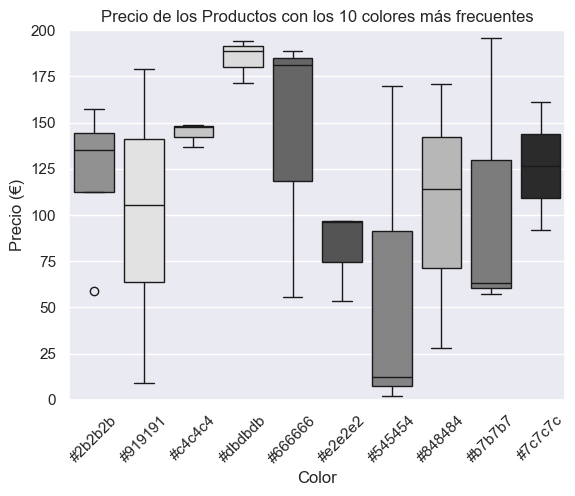

In [15]:
sns.boxplot(x=filtered_top_df["colour"], hue=filtered_top_df["colour"], y=filtered_top_df["price"], order=sorted_colours_top, palette=palette_top,legend=False)

plt.ylim(0, 200)
plt.xticks(rotation=45)
plt.xlabel("Color")
plt.ylabel("Precio (€)")
plt.title("Precio de los Productos con los 10 colores más frecuentes")
plt.show()

* Tambien voy a analizar el precio de los 10 colores menos frecuentes y para este caso he elegido un 'swarmplot' que me permite ver dichos colores representados como circulos cuyo tamaño puedo ajustar a mi conveniencia (ya que al solo disponer de un producto y por tanto de un solo precio para cada uno de estos colores un boxplot no tendría sentido).

* Mantengo plt.ylim() con el mismo rango que el gráfico anterior para que sean comparables ambos gráficos: los 10 productos más vendidos y los 10 productos menos vendidos.

* Como ya adelanté, exixten algunas formas de ajustar la apariencia de los circulos del gráfico a nuestra conveniencia, en este caso yo utilicé: 'size' que nos permite elegir el tamaño de los circulos, 'edgecolor' para añadir un color al borde de los círculos, y 'linewidth' que sirve para ajustar el grosor del borde.

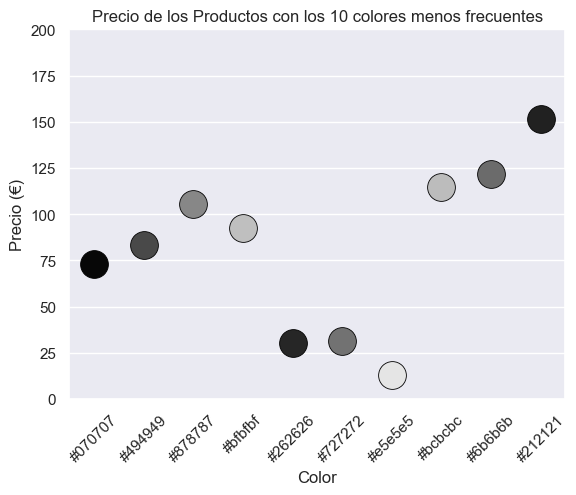

In [16]:
sns.swarmplot(x=filtered_bottom_df["colour"], hue=filtered_bottom_df["colour"], y=filtered_bottom_df["price"], order=sorted_colours_bottom, palette=palette_bottom, size=20, 
              edgecolor="black", linewidth=0.6, legend=False)

plt.ylim(0, 200) 
plt.xticks(rotation=45)
plt.xlabel("Color")
plt.ylabel("Precio (€)")
plt.title("Precio de los Productos con los 10 colores menos frecuentes")
plt.show()

Mi objetivo al realizar estos analisis de colores por precio de productos era descubrir si existía una coincidencia (positiva o negativa) entre los colores más o menos usados y su precio pero, como se puede observar a simple vista, tampoco existe ninguna relación en este sentido ya que ambas gráficas contienen un rago variado de precios en sus productos, lo que no nos permite observar ninguna tendencia en ninguno de los dos gráficos. 

### Exercici 5
Dues variables categòriques.

* Antes de comenzar a gráficar voy a crear una nueva variable categórica ('purchases') en la tabla 'users' que me informe de si los usuarios han realizado transacciones o no, ya que me interesa analizar un poco el perfil del usuario que se crea una cuenta y luego no realiza ninguna compra y se que tenemos algunos usuarios asi en nuestra base de datos.

* Para crear esta nueva variable uso la función 'merge' que me permite crear una nueva columna, en este caso con el 'id' de la tabla 'transaction' en la tabla 'users' para relacionar los usuarios y sus transacciones. Aquellos usuarios que no hayan realizado transacciones me saldrá el valos de esta nueva columna como nulo.

* Elimino la columna 'user_id' de 'transaction' porque al hacer el merge ahora estará duplicada en la tabla 'users' que ya tiene su columna de 'id' (porque está la columna inicial de la tabla 'users' y la que proviene de 'transaction').

In [25]:
users_df = users_df.merge(transaction_df[["user_id", "id"]], left_on="id", right_on="user_id", how="left")
users_df = users_df.drop(columns=["user_id"])
users_df


,id_x,name,surname,phone,email,birth_date,country,city,postal_code,adress,id_y
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,Lowell,73544,348-7818 Sagittis St.,NaN
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Des Moines,59464,903 Sit Ave,NaN
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Columbus,56518,736-2063 Tellus St.,NaN
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Kailua,77417,Ap #545-2244 Erat. Rd.,NaN
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Sandy,31564,341-2821 Ultrices Av.,NaN
...,...,...,...,...,...,...,...,...,...,...,...
641,275,Kenyon,Hartman,082-871-7248,convallis.ante.lectus@yahoo.com,1982-08-03,Canada,Richmond,R8H 2K2,8564 Facilisi. St.,DE684792-5DEE-5E12-D0B5-C5661D48F42A
642,275,Kenyon,Hartman,082-871-7248,convallis.ante.lectus@yahoo.com,1982-08-03,Canada,Richmond,R8H 2K2,8564 Facilisi. St.,E55E6DBD-788D-DC86-967E-228632CFD313
643,275,Kenyon,Hartman,082-871-7248,convallis.ante.lectus@yahoo.com,1982-08-03,Canada,Richmond,R8H 2K2,8564 Facilisi. St.,E6439B1C-C8F4-15B5-36ED-718482226631
644,275,Kenyon,Hartman,082-871-7248,convallis.ante.lectus@yahoo.com,1982-08-03,Canada,Richmond,R8H 2K2,8564 Facilisi. St.,EA2C3281-C9C1-A387-44F8-729FB4B51C76


* Uso 'groupby' para agrupar los datos por la id de usuario y no tener duplicados por culpa del 'merge', me quedaré solo con el primer id de transacción por usuario.

* Y finalmente creo la nueva columna ('purchases') que me diga si el usuario ha realizado transacciones o no a partir de la columna que contiene el 'id' de 'transaction' (si tiene id: si se han hecho transacciones, si es un valor nulo: no se han realizado transacciones); eliminando además, la columna con el id de transacciones quedandome solo con 'purchases' y renombrado la columna de 'id' de users cuyo nombre python me cambió a 'id_x' al hacer el merge de la tabla 'transaction' y añadirle otra columna también llamada 'id' a la que renombró como 'id_y' que se correspondía con el 'id' de 'transaction'. 

* En resumen: creo la columna 'purchases' (que me informa si se han realizado transacciones o no por los usuarios), elimino la columna 'id_y' (que es el 'id' de la tabla 'transaccion') y renombro id_x que es el 'id' de la tabla 'users'.

In [26]:
users_df = users_df.groupby('id_x').agg('first').reset_index() 
users_df["purchases"] = np.where(pd.notna(users_df["id_y"]), "Yes", "No")
users_df = users_df.drop(columns=["id_y"])
users_df = users_df.rename(columns={"id_x": "id"})
users_df

,id,name,surname,phone,email,birth_date,country,city,postal_code,adress,purchases
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,Lowell,73544,348-7818 Sagittis St.,No
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Des Moines,59464,903 Sit Ave,No
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Columbus,56518,736-2063 Tellus St.,No
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Kailua,77417,Ap #545-2244 Erat. Rd.,No
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Sandy,31564,341-2821 Ultrices Av.,No
...,...,...,...,...,...,...,...,...,...,...,...
270,271,Leandra,Cherry,089-285-7016,lobortis.quis@hotmail.ca,1991-09-02,Canada,Gander,H6S 6M9,554-9293 Sollicitudin Av.,Yes
271,272,Hedwig,Gilbert,064-204-8788,sem.eget@icloud.edu,1991-04-16,Canada,Tuktoyaktuk,Q4C 3G7,"P.O. Box 496, 5145 Sapien Road",Yes
272,273,Hilary,Ferguson,060-710-1604,sapien.molestie.orci@google.edu,1981-11-03,Canada,Pangnirtung,12T 5G4,Ap #736-4628 Cras St.,Yes
273,274,Jameson,Hunt,024-732-2321,fringilla@protonmail.com,1982-01-29,Canada,Township of Minden Hills,B6V 6N4,224-4927 Praesent Ave,Yes


* En este caso trabajaré con las variables: 'country' y 'purchases' de la tabla: 'users' y las representaré en un gráfico de barras porque quiero ver la cantidad de compras según el país del usuario.

* Creo la tabla 'crosstab' para ver la distribución de mis datos y luego visualizo estos datos en el gráfico

In [27]:
pd.crosstab(users_df['country'], users_df['purchases'])

purchases,No,Yes
country,,
Canada,0,75
United Kingdom,0,50
United States,59,91


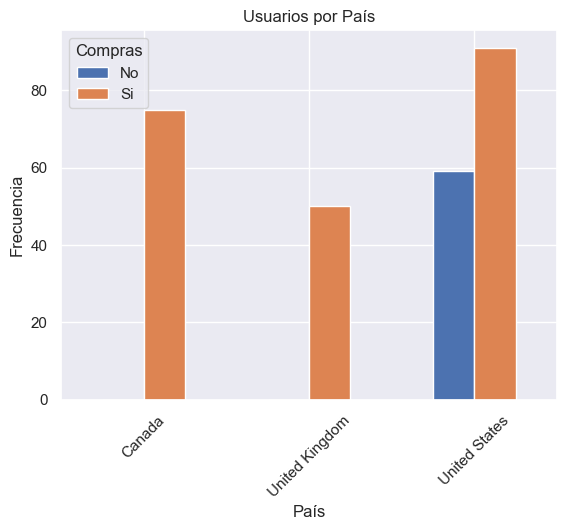

In [28]:
pd.crosstab(users_df['country'], users_df['purchases']).plot.bar()

plt.xticks(rotation=45)
plt.ylabel("Frecuencia")
plt.xlabel("País")
plt.title("Usuarios por País")
plt.legend(title="Compras", labels=["No", "Si"])
plt.show()

Este gráfico nos da bastante información sobre las compras de los usuarios según su país de origen. Por ejemplo: el país con menos usuarios es Reino unido con una frecuencia de alrededor de 50 usuarios los cuales han realizado todos compras. Por otra parte Canadá tiene una frecuencia de usuarios mayor (casi 80) y también han realizado todos compras. Pero lo más interesante de este gráfico son los usuarios de EUA, que son los que presentan una frecuencia mayor (más de 140 en total) pero una gran parte de ellos no han realizado compras, aun asi la cantidad de usuarios que compran sigue siendo mayor que los usuarios de Canadá y Reino Unido.

Como hemos podido observar, todos los usuarios que se registran y no realizan compras son de EUA, lo que nos plantea la duda de porqué ocurre esto y quizas necesitaríamos analizar que estrategia de marketing los está atrayendo que no hace que también compren.

### Exercici 6
Tres variables.

* Quiero añadir las variables 'declined' y 'amount' de la tabla 'transactions' en 'users' pero esto traería consigo la duplicación de resultados asi que voy a crear un nuevo dataframe con las columnas de la tabla 'users' al que añadiré las columnas que me interesan de 'transaction'.

* Para esto primero uso 'merge' en el nuevo dataframe basado en 'users' ('users_trans_df') al que añado una nueva columna con las transacciones y las declinadas por usuario para saber cuantos usuarios tienen transacciones declinadas.

* También sustituyo los nulos de 'declined' por 0.0 porque si no han realizado transacciones no pueden tenerlas declinadas y lo mismo para 'amount' (si no hay ventas, las ventas son 0).

* Y elimino las columnas de este dataframe que no necesitaré para futuros análisis y las que están duplicadas ('user_id').

In [31]:
users_trans_df = users_df.merge(transaction_df[["user_id", "declined", "amount"]], left_on="id", right_on="user_id", how="left")
users_trans_df['declined'] = users_trans_df['declined'].fillna(0.0)
users_trans_df['amount'] = users_trans_df['amount'].fillna(0.0)
users_trans_df = users_trans_df.drop(['phone', 'email', 'birth_date', 'postal_code', 'adress', 'user_id'], axis=1) 
users_trans_df

,id,name,surname,country,city,purchases,declined,amount
0,1,Zeus,Gamble,United States,Lowell,No,0.0,0.00
1,2,Garrett,Mcconnell,United States,Des Moines,No,0.0,0.00
2,3,Ciaran,Harrison,United States,Columbus,No,0.0,0.00
3,4,Howard,Stafford,United States,Kailua,No,0.0,0.00
4,5,Hayfa,Pierce,United States,Sandy,No,0.0,0.00
...,...,...,...,...,...,...,...,...
641,275,Kenyon,Hartman,Canada,Richmond,Yes,0.0,71.55
642,275,Kenyon,Hartman,Canada,Richmond,Yes,1.0,356.09
643,275,Kenyon,Hartman,Canada,Richmond,Yes,0.0,266.09
644,275,Kenyon,Hartman,Canada,Richmond,Yes,1.0,119.36


* Esta vez trabajaré con las variables: 'country', 'purchases' y 'declined' de la tabla 'users_trans' (modificación de la tabla 'users') y los representaré con un violinplot porque quiero ver la cantidad de compras según el país del usuario y cuantas de estas son declinadas.

* ax.get_legend_handles_labels() nos permite obtener los elementos de la leyenda y new_labels modifica las etiquetas de la leyenda para visualizarlas en el orden deseado.

* bbox_to_anchor=(1,1) mueve la leyenda fuera del para que no dificulte la observación del mismo.

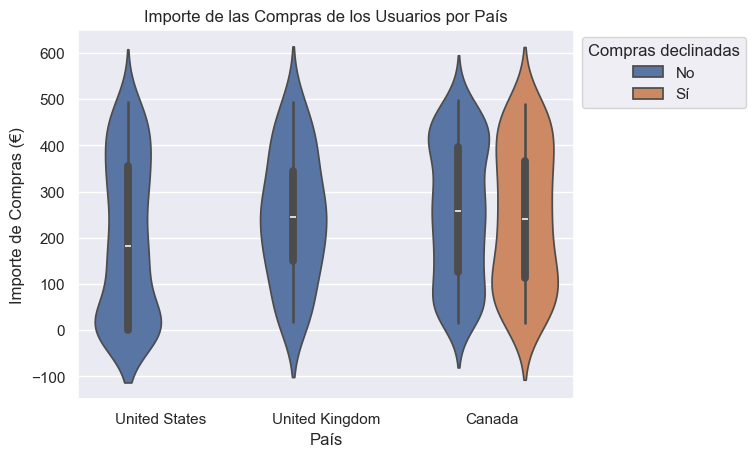

In [32]:
ax = sns.violinplot(users_trans_df, x='country', y= 'amount', hue='declined')

plt.ylabel("Importe de Compras (€)")
plt.xlabel("País")
plt.title("Importe de las Compras de los Usuarios por País")
handles, labels = ax.get_legend_handles_labels()
new_labels = ["No", "Sí"] 
plt.legend(handles, new_labels, title="Compras declinadas", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

En este gráfico podemos observar que solo Canadá (de los tres países de origen de nuestros usuarios) tiene compras declinadas, mientras que Reino unido y EUA solo tienen compras que no han sido declinadas. Es importante recordar que EUA tiene varios usuarios que no han realizado compras y por tanto no pueden tenerlas declinadas; lo ideal quizas sería eliminar estos datos del análisis porque no son del todo comparables con los datos de los usuarios que si han realizado compras pero como quería ver los datos totales y comparar este gráfico con el anterior los he dejado (pero en realidad nos afecta a la forma del violinplot de EUA y a la media de los datos también). Es por eso que el el violinplot de EUA se observa un engrosamiento en la base (que se corresponde con el importe de compras = 0) que serían los usuarios que no han realizado ninguna compra.

De este gráfico lo más interesante me parece que son los violinplot de Canadá que son bastante similares entre las transacciones declinadas y las aceptadas (o no declinadas), lo cual no nos pemite determinar si existe algun patrón entre los usuarios que tienen transacciones declinadas. Y la comparación entre los patrones de compra de los países del continente americano (EUA y Canadá) que presentan una alta densidad de compras con importes extremos (altos y bajos) y el país del continente europeo (Reino Unido) presenta una mayor densidad en los importes de compra medios; lo cual nos da una información valiosa sobre el perfil del comprador de estos dos contienentes que parece ser diferente y que quizas convenga una diferente forma de captación y mantenimiento de los usuarios.

### Exercici 7
Graficar un Pairplot.

* El pairplot es un tipo de gráfico que nos muestra la relación entre varias variables numéricas, y en este caso yo estoy interesada en seguir explorando la relación entre las variables numéricas de la tabla 'products'.

* Pero primero voy a crear una nueva columna calculada en 'products' a partir de la cantidad de 'id_transaction' segun producto de la tabla 'sales'. Para esto uso 'groupby' y 'count', creo un nuevo dataframe a partir de 'sales' para saber cuantas veces se ha vendido cada producto y luego uso 'merge' para añadir la columna de las ventas calculadas por producto a la tabla 'products'. 

* También elimino 'products_id' porque está duplicada y creo una columna con los valores boleanos (de si hay compra o no) para añadirla como filtro a nuestro pairplot ('sales_bool')

* Sustituyo los valores nulos de nuestra columna calculada de ventas (sales_count) por 0 y convierto los valores en enteros porque al tratarse de compras no pueden ser decimales.


In [37]:
sales_count = sales_df.groupby("product_id")["transaction_id"].count().reset_index()
sales_count.rename(columns={"transaction_id": "sales_count"}, inplace=True)

products_df = products_df.merge(sales_count, left_on="id", right_on="product_id", how="left")
products_df.drop(columns=["product_id"], inplace=True) 
products_df['sales_bool'] = np.where(pd.notna(products_df["sales_count"]), "Yes", "No")
products_df['sales_count'] = products_df['sales_count'].fillna(0)
products_df['sales_count'] = products_df['sales_count'].astype(int)
products_df

,id,product_name,price,colour,weight,warehouse_id,sales_count,sales_bool
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,56,Yes
1,10,Karstark Dorne,119.52,#f4f4f4,2.4,WH--5,0,No
2,100,south duel,40.43,#6d6d6d,3.0,WH--95,0,No
3,11,Karstark Dorne,49.70,#141414,2.7,WH--6,46,Yes
4,12,duel Direwolf,181.60,#a8a8a8,2.1,WH--7,0,No
...,...,...,...,...,...,...,...,...
95,95,riverlands north Direwolf,6.90,#c1c1c1,2.7,WH--90,0,No
96,96,dooku solo,20.92,#282828,2.1,WH--91,0,No
97,97,jinn Winterfell,65.25,#bababa,1.0,WH--92,56,Yes
98,98,Direwolf Littlefinger,38.33,#bababa,2.0,WH--93,0,No


* También me interesa saber que productos han sido declinados asi que añado la columna 'declined' a través de un merge de la tabla 'transaction' a la tabla 'products'.

* Elimino la columna 'products_id' porque está duplicada.

* Utilizo .agg('max') para asegurarme de que cuando se agrupen los registros si existen valores de 0, 1 y NaN en la columna 'declined' para un mismo 'id' de producto, se mantendrá el valor 1 ya que es el valor máximo, porque me interesa saber que productos han sido declinados al menos una vez; y .reset_index() nos restaura los valores del indice al eliminar los registros de 'id' duplicados.

* Por último, creo una columna con los valores boleanos de si hay compra declinada o no ('declined_bool') a partir de los valores de 0 y 1 de la columna 'declined' y elimino esta última porque trabajaré con los valores boleanos.

In [39]:
products_df = products_df.merge(transaction_df[["products_id", "declined"]], left_on="id", right_on="products_id", how="left")
products_df.drop(columns=["products_id"], inplace=True) 
products_df = products_df.groupby('id').agg('max').reset_index()
products_df["declined_bool"] = np.where(pd.notna(products_df["declined"]), "Yes", "No")
products_df = products_df.drop(columns=["declined"])
products_df

,id,product_name,price,colour,weight,warehouse_id,sales_count,sales_bool,declined_bool
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,56,Yes,Yes
1,10,Karstark Dorne,119.52,#f4f4f4,2.4,WH--5,0,No,No
2,100,south duel,40.43,#6d6d6d,3.0,WH--95,0,No,No
3,11,Karstark Dorne,49.70,#141414,2.7,WH--6,46,Yes,Yes
4,12,duel Direwolf,181.60,#a8a8a8,2.1,WH--7,0,No,No
...,...,...,...,...,...,...,...,...,...
95,95,riverlands north Direwolf,6.90,#c1c1c1,2.7,WH--90,0,No,No
96,96,dooku solo,20.92,#282828,2.1,WH--91,0,No,No
97,97,jinn Winterfell,65.25,#bababa,1.0,WH--92,56,Yes,Yes
98,98,Direwolf Littlefinger,38.33,#bababa,2.0,WH--93,0,No,No


* Ahora que ya tengo todas las columnas que me interesa analizar en mi tabla 'products' visualizo mi pairplot con las variables numéricas: 'price', 'weight' y 'sales_count' (que se corresponden con el precion, el peso, y la cantidad de veces que se ha comprado el producto respectivamente) y filtro estas relaciones por la variable categorica 'declined_bool' que nos da información de los productos que han tenido alguna venta declinada.

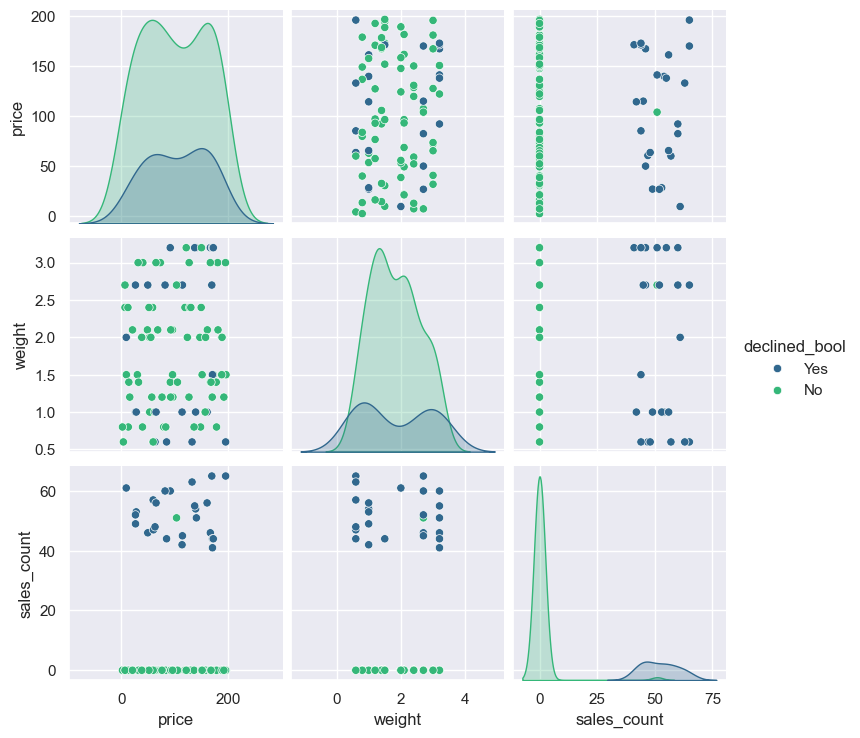

In [ ]:
sns.pairplot(products_df, hue='declined_bool', palette='viridis')
plt.show()

Con esta visualización observamos que no hay relacion a simple vista entre las variables numéricas y tampoco parece influir ninguna de ellas en el hecho de que un producto sea declinado o no, ya que tanto en el precio como en el peso podemos observar que las ventas declinadas (puntos azules) se encuentran en un rango bastante amplio. Además observamos que las no declinadas (puntos verdes) en las tablas de cantidad de productos vendidos se corresponden en su mayoría con los productos que no tienen ventas, esto nos informa que la mayoría de productos han sido declinados al menos una vez en alguna transaccion. Es muy interesante que existe un registro de un producto que si ha sido vendido al rededor de unas 50 veces cuyo precio debe rondar los 100€ que nunca ha sido declinado, sería interesnte quizas estudiarlo más a fondo.

También me parece interesante en relacion a la cantidad de veces que se compran los productos que el rango (sin tener en cuenta los que no se han comprado nunca que son bastantes por cierto) va de 40 a más de 60 veces vendidos. O sea, que los productos que se venden se venden mucho, sin embargo, se debería analizar esa lista de productos que no se han vendido nunca porque quizas no nos interesa tenerlos en nuestro stock o habría que mejorar nuestra estrategia de marketing para ellos.

### Nivell 2

### Exercici 1

Correlació de totes les variables numèriques.

* Como quiero profundizar en las relaciones de las variables graficadas en el ejercicio anterior, lo primero que hago es crear un dataset con los valores numéricos del dataframe 'products'.

In [41]:
products_num_df = products_df.select_dtypes(include=["number"])
products_num_df.head()

,price,weight,sales_count
0,161.11,1.0,56
1,119.52,2.4,0
2,40.43,3.0,0
3,49.70,2.7,46
4,181.60,2.1,0


* Posteriormente, teniendo en cuenta que existen diferentes tipos de correlaciones y no tengo información suficiente de mis datos para elegir cuál es más adecuada, voy a crear 3 nuevas variables que contengan los 3 principales tipos de correlación:

1. Correlación de Pearson: requiere datos cuantitativos y distribución normal.
2. Correlación de Spearman: no asume normalidad, pero sí relación.
3. Correlación de Kendall: para datos con muchos valores atípicos o tamaño muestral pequeño.

* Por defecto .corr() usa el coeficiente de correlación de Pearson pero se puede cambiar para especificarle el metodo que queremos utilizar añsdiendo por ejemplo method="spearman" dentro del parentesis.

In [45]:
correlacion_pearson = products_num_df.corr() 
correlacion_spearman = products_num_df.corr(method="spearman")
correlacion_kendall = products_num_df.corr(method="kendall")

print(f"Correlación de Pearson:\n", correlacion_pearson)
print(f"\nCorrelación de Spearman:\n", correlacion_spearman)
print(f"\nCorrelación de Kendall:\n", correlacion_kendall)

Correlación de Pearson:
                 price    weight  sales_count
price        1.000000  0.105431     0.032642
weight       0.105431  1.000000     0.014803
sales_count  0.032642  0.014803     1.000000

Correlación de Spearman:
                 price    weight  sales_count
price        1.000000  0.110476     0.028369
weight       0.110476  1.000000    -0.019121
sales_count  0.028369 -0.019121     1.000000

Correlación de Kendall:
                 price    weight  sales_count
price        1.000000  0.078951     0.018915
weight       0.078951  1.000000    -0.014355
sales_count  0.018915 -0.014355     1.000000


* Visualizo las correlaciones con heatmap, creando primero un subplot con 1 fila y 3 columnas en cada una de las cuales tendré un heatmap, para asi poder ver las 3 correlaciones en una sola imagen.

* Con plt.tight_layout() ajusto el diseño para que ocupe toda el espacio de nuestro subplot.

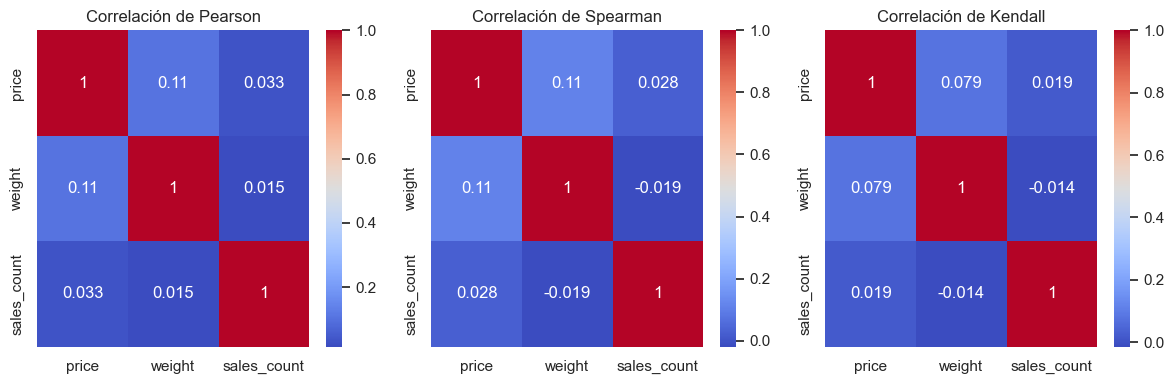

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 

sns.heatmap(correlacion_pearson, ax=axes[0], cmap="coolwarm", annot=True)
axes[0].set_title("Correlación de Pearson")

sns.heatmap(correlacion_spearman, ax=axes[1], cmap="coolwarm", annot=True)
axes[1].set_title("Correlación de Spearman")

sns.heatmap(correlacion_kendall, ax=axes[2], cmap="coolwarm", annot=True)
axes[2].set_title("Correlación de Kendall")

plt.tight_layout() 
plt.show()

Para interpretar los datos hay que tener en cuenta que:
1. Valores cercanos a 1 = Fuerte correlación positiva 
2. Valores cercanos a -1 = Fuerte correlación negativa 
3. Valores cercanos a 0 = No hay relación significativa

Si observamos los heatmap y tenemos en cuenta como se ha de hacer la interpretación de los datos podemos concluir que (tal como sospechabamos a partir del gráfico del ejercicio anterior) no existe correlación entre los valores numéricos estudiados, ya que todos los valores, tanto positivos como negativos, se encuentran muy lejos del 1 o del -1.

### Exercici 2

Implementa un jointplot.

* Un jointplot es un tipo de gráfico que se usa para visualizar la relación entre dos variables con diagramas combinados. Normalmente, muestra un gráfico de dispersión (scatter plot) en el centro y distribuciones univariadas en los ejes superior y lateral, pero existen variantes.

* En mi caso he decidido seguir visualizando los datos de la gráfica 'products' y esta vez he elegido las variables 'price' y 'sales_count' para examinar mas detalladamente su relación por su puedo detectar algún patron que no haya podido ver antes. Por esto, he decidido hacer diferentes tipos de jointplot para visualizar los mismos datos:

1. Scatter plot + histogramas en los ejes
2. Scatter plot con recta de regresión lineal + histogramas y tendencia en los ejes
3. Densidad (Kde)

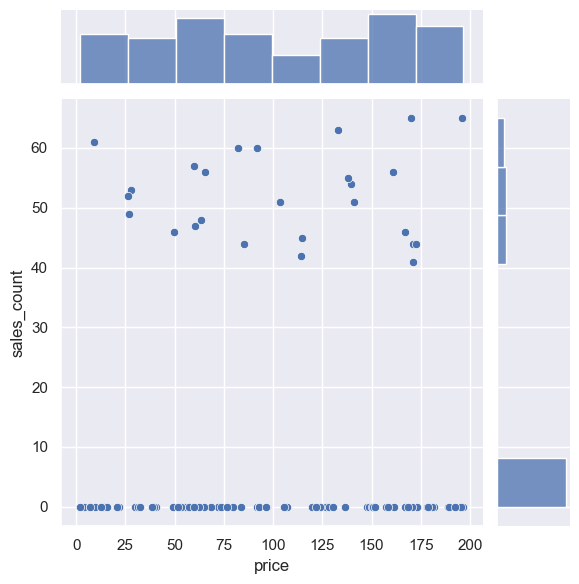

In [ ]:
sns.jointplot(data=products_df, x="price", y="sales_count", kind="scatter")
plt.show() 

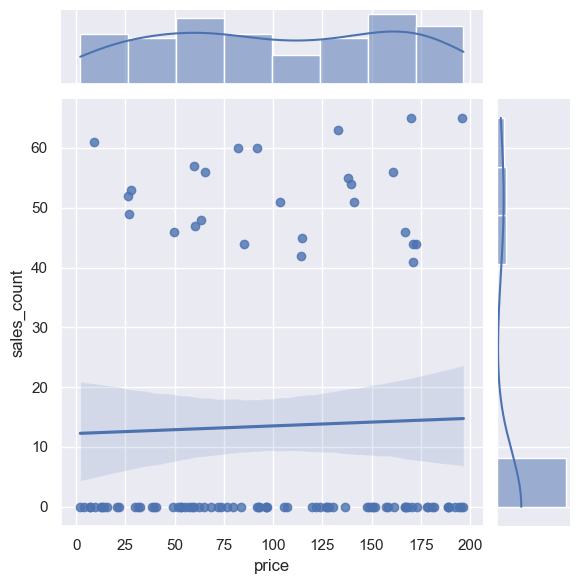

In [ ]:
sns.jointplot(data=products_df, x="price", y="sales_count", kind="reg")
plt.show() 

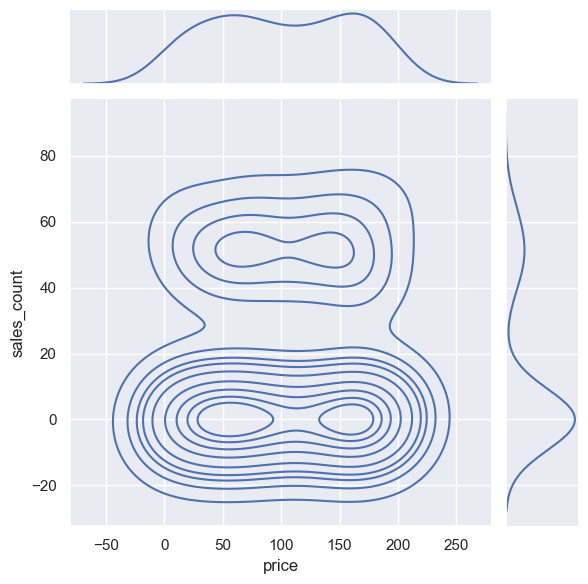

In [ ]:
sns.jointplot(data=products_df, x="price", y="sales_count", kind="kde")
plt.show() 

Analizando los tres gráficos ampliamos la información sobre los productos que no han sido comprados antes, ya que se puede observar a simple vista que la mayor cantidad de productos se encuentran en el grupo de los que no tienen ninguna venta. Lo cual nos indica que es primordial y urgente mejorar nuestra estrategia de marketing ya que la mayoría de productos no se están vendiendo.

Por otro lado confirmamos la falta de relación entre el precio y la cantidad de productos vendidos.

### Nivell 3

### Exercici 1

Implementa un violinplot combinat amb un altre tipus de gràfic.

* Para este ejercicio quiero volver a analizar la tabla 'users' pero voy a utilizar la tabla modificada que creé anteriormente y que incluye la variable 'purchases' que indica si el usuario ha realizado alguna compra o no, la variable 'declined' que indica si el usuario tiene transacciones declinadas o no y la variable 'amount' que indica el valor de las compras que ha realizado por cada transacción realizada por cada usuario en €.

* Voy a visualizar los datos de 'country' y 'amount' utilizando un Violinplot + Stripplot (gráfico de puntos individuales) que sirven para visualizar la distribución y dispersión de los datos en una sola gráfica. Esta combinación ayuda a detectar valores atípicos y muestra la distribución de los puntos individuales dentro de cada grupo.

* inner=None oculta los puntos internos del violinplot para que no se mezclen con los del stripplot.
* jitter=True dispersa ligeramente los puntos para que no se superpongan. 
* alpha=0.5 define la transparencia de los puntos (en este cado transparencia media).
* size=3 define el tamaño de los puntos.


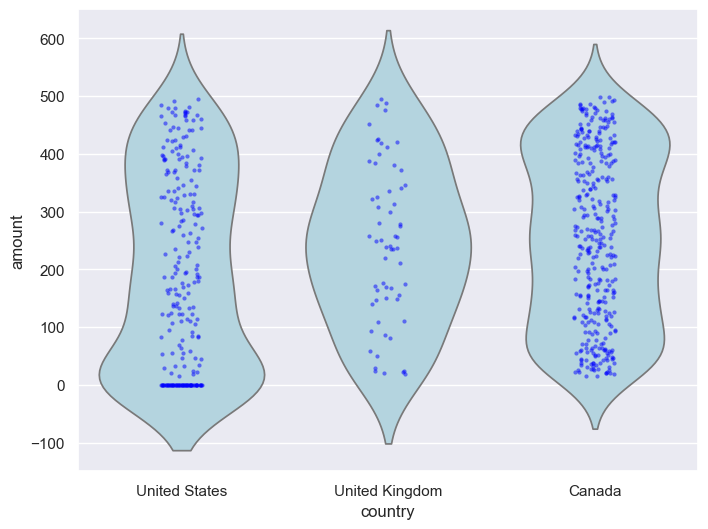

In [47]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=users_trans_df, x='country', y= 'amount', inner=None, color="lightblue") 
sns.stripplot(data=users_trans_df, x='country', y= 'amount', color="blue", alpha=0.5, jitter=True, size=3)
plt.show()

Mi objetivo con esta visualización era confirmar lo que ya había observado el el gráfico de violin del ejercicio 6 del nivel 1 con respecto a la distribución de las compras de los usuarios en los diferentes países.

Tal y como ya habíamos detectado en varias ocaciones anteriores EUA es el unico de los tres países con varios usuarios que no han realizado compras y esto puede observarse tanto en la cantidad de puntos que se corresponden con el valor 0 de amount como en el emsanchamiento del violin indicando aumento de densidad en esa zona.

Tambien podemos confirmar, gracias a la cantidad de puntos del stripplot, que el país con más transacciones realizadas en Canadá (aunque sabemos que muchas de ellas son transacciones declinadas) y que el que tiene menos en Reino Unido. Que además, como ya habíamos advertido anteriormente, EUA y Canadá presentan un patrón de compras muy similar (alta densidad de compras con importes extremos: altos y bajos) y por lo contrario Reino Unido presenta un patrón muy diferente (caracterizado por una mayor densidad en los importes de compra medios) lo cual nos indica perfiles de comprador diferentes y nos sugiere un estudio de mercado diferente para estos.


### Exercici 2

Genera un FacetGrid per a visualitzar múltiples aspectes de les dades simultàniament.

* Al pensar en realizar un facetgrid detecte que existe una variable que sería muy importante a la hora de hacer estudios de mercado basados en nuestros clientes y de la cual no disponemos. Es por ello que decidí crearla como si realmente hubiera sido obtenida por nuestros clientes.

* Se trata de la variable 'gender', para crearla, con ayuda de chatGPT y basandome en los nombres de los usuarios creé dos listas que me permitieran clasificar los nombres en femenino o masculino y luego añadí esta clasificación a mi tabla 'users' como si hubiese sido un dato obtenido de los usuarios. Esto lo hice en varios pasos:
1. Generé una lista con los valores de nombre únicos (que no hubiera nombres repetidos).
2. Le pasé esta lista a ChatGPT y le pedí que me clasificara los nombres en femenino o masculino y me los separara en 2 listas diferentes.
3. Utilicé un bucle para que python me creara una columna nueva ('gender') en la tabla 'users' y basandose en el nombre de cada registro y comparandolo con las tablas de nombres masculinos('male_names') y nombres femeninos ('female_names') me añadiera el genero ('Male' o 'Female') a dicha columna nueva para cada registro.

In [48]:
names = users_trans_df['name'].unique().tolist()
print(names)

['Zeus', 'Garrett', 'Ciaran', 'Howard', 'Hayfa', 'Joel', 'Rafael', 'Nissim', 'Mannix', 'Robert', 'Joan', 'Benedict', 'Allegra', 'Sara', 'Noelani', 'Eric', 'Bruce', 'Russell', 'Nicholas', 'Kelsey', 'Hall', 'Allistair', 'Kelsie', 'Nolan', 'Wanda', 'Aquila', 'Diana', 'Elmo', 'Deacon', 'Martena', 'Francis', 'Chase', 'Venus', 'Sopoline', 'Yvonne', 'Raymond', 'Graiden', 'Abra', 'Nyssa', 'Astra', 'Uriel', 'Lucy', 'Jayme', 'Richard', 'Alika', 'Herrod', 'Patrick', 'Lev', 'Aretha', 'Lionel', 'Sheila', 'Lucas', 'Emma', 'Barrett', 'Odysseus', 'Daquan', 'Sandra', 'Heather', 'Roth', 'Duncan', 'Phyllis', 'Beverly', 'Irma', 'Yeo', 'Bert', 'Kenneth', 'Whoopi', 'Stone', 'Debra', 'Emerson', 'Jael', 'Warren', 'Zelenia', 'Colleen', 'Glenna', 'Jared', 'Camilla', 'Preston', 'Sophia', 'Acton', 'Stacey', 'Dana', 'Craig', 'Dawn', 'Quintessa', 'Camden', 'Holmes', 'Lars', 'Serina', 'Lynn', 'Kimberley', 'Kim', 'Brennan', 'Joseph', 'Cassandra', 'Reed', 'Melodie', 'Sarah', 'Jasper', 'Upton', 'Martha', 'Hashim', 'Tan

In [49]:
male_names = ['Zeus', 'Garrett', 'Ciaran', 'Howard', 'Joel', 'Rafael', 'Nissim', 'Mannix', 'Robert', 'Benedict', 'Bruce', 'Russell', 'Nicholas', 'Hall', 'Allistair', 'Nolan', 
              'Francis', 'Chase', 'Raymond', 'Graiden', 'Abra', 'Lev', 'Lionel', 'Barrett', 'Odysseus', 'Daquan', 'Roth', 'Duncan', 'Kenneth', 'Whoopi', 'Stone', 'Neil', 
              'Emerson', 'Warren', 'Preston', 'Acton', 'Craig', 'Quintessa', 'Camden', 'Holmes', 'Lars', 'Joseph', 'Reed', 'Jasper', 'Upton', 'Victor', 'Germaine', 'Ryder', 
              'Sacha', 'Halla', 'Solomon', 'Dominique', 'Walter', 'Oscar', 'Hiram', 'Tiger', 'Brody', 'Wesley', 'Walker', 'Wyatt', 'Kerry', 'Joshua', 'Philip', 'Denton', 
              'William', 'Brent', 'Kermit', 'Dane', 'Germane', 'Stuart', 'Maxwell', 'Jarrod', 'Burke', 'Slade', 'Zeph', 'Ivan', 'Sasha', 'Theodore', 'Linus', 'Wade', 'Dean', 
              'Griffith', 'Drake', 'Chester', 'Andrew', 'Allen', 'John', 'Brett', 'Kenyon', 'Jayme', 'Lucas', 'Phyllis', 'Bert', 'Jael', 'Hashim', 'Elton', 'Brock', 'Cooper',
              'Joshua', 'Gary', 'Maxwell', 'Leonard', 'Porter', 'Neville', 'Zane''Jameson', 'Joan', 'Eric', 'Richard', 'Patrick', 'Jared', 'Brennan', 'Damian', 'Ezra', 'Zahir', 
              'Clark', 'Matthew', 'David', 'Keane', 'Elijah', 'Alan', 'Zane', 'Aquila', 'Elmo', 'Deacon', 'Uriel', 'Oleg', 'Hakeem', 'Lael', 'Dale', 'Jameson', 'Herrod' ]
female_names = ['Hayfa', 'Sara', 'Noelani', 'Allegra', 'Emma', 'Diana', 'Martena', 'Venus', 'Sopoline', 'Yvonne', 'Nyssa', 'Astra', 'Lucy', 'Alika', 'Aretha', 'Sheila', 'Sandra', 
                'Heather', 'Beverly', 'Irma', 'Yeo', 'Debra', 'Zelenia', 'Camilla', 'Sophia', 'Stacey', 'Dawn', 'Lynn', 'Kimberley', 'Kim', 'Cassandra', 'Sarah', 'Martha', 'Tanner', 
                'Germaine', 'Raven', 'Risa', 'Jasmine', 'Halla', 'Brooke', 'Desiree', 'Celeste', 'Amber', 'Gisela', 'Iona', 'Sonya', 'Genevieve', 'Ursula', 'Priscilla', 
                'Meghan', 'Keegan', 'Fatima', 'Kylynn', 'Nora', 'Francesca', 'Donna', 'Linda', 'Yoko', 'Bertha', 'Amal', 'Lisandra', 'Guinevere', 'Amelia', 'Molly', 'Deirdre', 
                'Phoebe', 'Minerva', 'Rosalyn', 'Blaze', 'Carly', 'Keely', 'Lewis', 'Nero', 'Iola', 'Harper', 'Athena', 'Larissa', 'Tana', 'Avye', 'Sonia', 'Willa', 'Idola', 'Zoe', 
                'Gemma', 'Jada', 'Rhea', 'Hilda', 'Zephania', 'Violet', 'Ima', 'Keiko', 'Chloe', 'Aiko', 'Ocean', 'Haley', 'Leandra', 'Hedwig', 'Hilary', 'Sheila', 'Zelenia', 'Colleen', 
                'Dana', 'Serina', 'Melodie', 'Urielle', 'Oprah', 'Jeanette', 'Remedios',  'Harper', 'Blake', 'Xandra', 'Lane', 'Wanda', 'Shellie', 'Cleo', 'Melissa', 'Olga', 'Grace',
                'Kelsie', 'Kelsey', 'Glenna', 'Ainsley', 'Ulla', 'Ursa',  'Medge']

users_trans_df['gender'] = users_trans_df['name'].apply(lambda x: 'Male' if x in male_names else ('Female' if x in female_names else 'Unknown'))
users_trans_df

,id,name,surname,country,city,purchases,declined,amount,gender
0,1,Zeus,Gamble,United States,Lowell,No,0.0,0.00,Male
1,2,Garrett,Mcconnell,United States,Des Moines,No,0.0,0.00,Male
2,3,Ciaran,Harrison,United States,Columbus,No,0.0,0.00,Male
3,4,Howard,Stafford,United States,Kailua,No,0.0,0.00,Male
4,5,Hayfa,Pierce,United States,Sandy,No,0.0,0.00,Female
...,...,...,...,...,...,...,...,...,...
641,275,Kenyon,Hartman,Canada,Richmond,Yes,0.0,71.55,Male
642,275,Kenyon,Hartman,Canada,Richmond,Yes,1.0,356.09,Male
643,275,Kenyon,Hartman,Canada,Richmond,Yes,0.0,266.09,Male
644,275,Kenyon,Hartman,Canada,Richmond,Yes,1.0,119.36,Male


* Compruebo que todos los nombres tienen un genero asignado:

In [50]:
users_trans_df['gender'].unique()

array(['Male', 'Female'], dtype=object)

* Creo una variable 'order_gender' para decirle al FacetGrid como ordenar los valores de 'gender'.

* Y creo mi FacetGrid utilizando las variables 'amount', 'declined', 'country' y 'gender' de los usuarios.

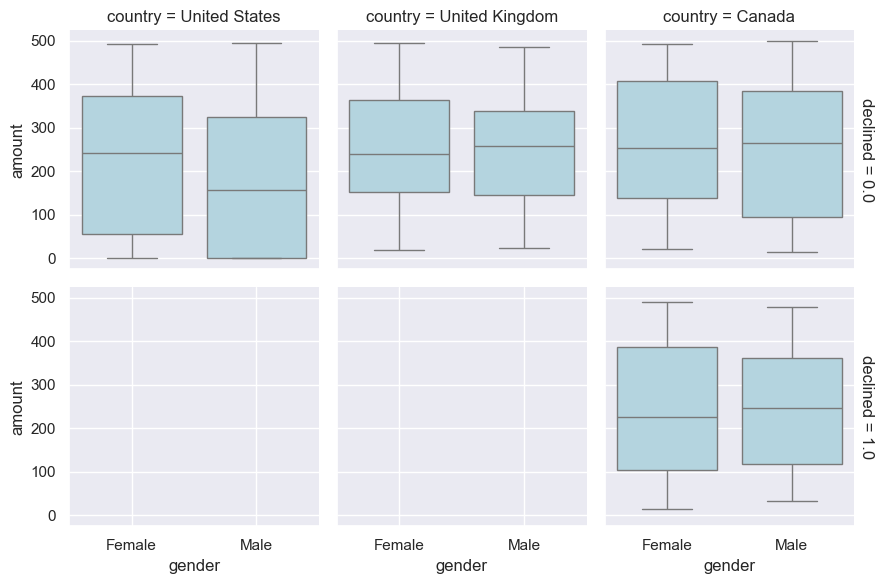

In [52]:
g = sns.FacetGrid(users_trans_df, col="country", row="declined", margin_titles=True)
order_gender=["Female", "Male"]
g.map(sns.boxplot, "gender", "amount", order=order_gender, color="lightblue")
plt.show()


Lo que me interesaba al realizar esta visulización era ver si al segmentar los datos por genero se podrían extraer algunas otras coclusiones (hemos de tener en cuenta que 'gender' no es una columna real, sino creada por mi, y existen nombres neutros o que llevan a confución dependiendo del idioma, es por eso que las conclusiones que pueda extraer de ellos no son 100% fiables).

Si observamos los boxplot de EUA podríamos concluir que las mujeres gastan más a la hora de realizar sus compras y que el mayor número de uduarios que no han realizado ninguna compra seguramente sean hombres porque el limite inferior del boxplot concuerda con el valor de 'amount' cero.

En el caso de Reino Unido no parece haber grandes diferencias entre hombres y mujeres pero si parece que la media de calor de las compras sea mayor en hombres (como que los hombres hacen compras relativamente mas caras).

Por ultimo en el caso de Canadá tenemos transacciones declinadas y no declinadas, si nos fijamos en estas últimas el rango de precios de los productos coimprados por hombres es más amplio pero no se observan diferencias entre los valores medios de compras entre hombres y mujeres; pero en el caso de las declinadas es al revés: el rango de precios de las compras de las mujeres es más amplio, sin embargo la media del valor de las compras declinadas en los hombres parce mayor.

Sería interesante contar con esta variable realmente porque si obtuvieramos estos datos yo recomendaria por ejemplo potenciar la extrategia de marketing en EUA para captar más clientes masculinos que compren y no solo se registren.